Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 找到 ZIP 文件，正在解压...
🎉 解压完成！
📍 训练路径: /content/dataset_temp/chest_xray/train
📍 测试路径: /content/dataset_temp/chest_xray/test
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🚀 开始模型训练...
Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 499ms/step - accuracy: 0.8004 - loss: 0.4609 - val_accuracy: 0.7500 - val_loss: 0.6907
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 441ms/step - accuracy: 0.8890 - loss: 0.2656 - val_accuracy: 0.7500 - val_loss: 0.5762
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.9036 - loss: 0.2334 - val_accuracy: 0.8125 - val_loss: 0.5458
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9201 - loss: 0.2080 - val_accuracy: 0.8125 - val_loss: 0.4653
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9281 - loss: 0.1814 - val_accuracy: 0.6250 - val_loss: 0.8290
Epoch 6/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 442ms/step - accuracy: 0.9258 - loss: 0.1873 - val_accuracy: 0.7500 - val_loss: 0.5870
Epoch 7/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 437ms/step - accuracy: 0.9381 - loss: 0.1589 - val_accuracy: 0.5625 - val_loss: 0.8438
Epoch 8/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.9

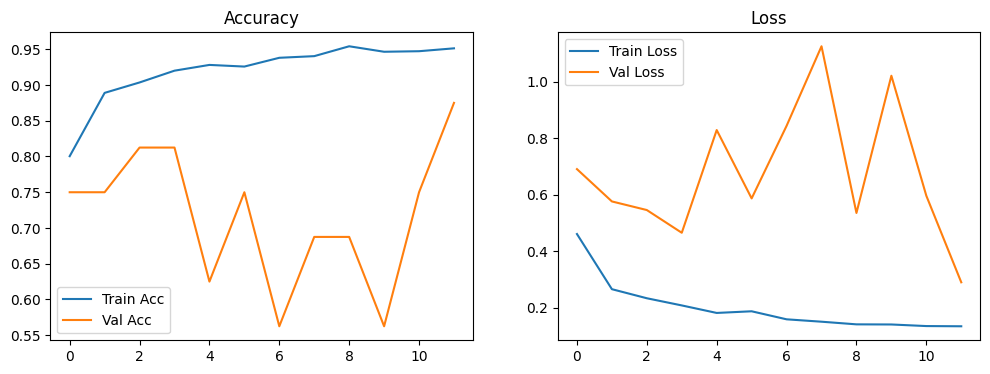

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step

实验报告指标
              precision    recall  f1-score   support

      Normal       0.94      0.87      0.90       234
   Pneumonia       0.93      0.96      0.94       390

    accuracy                           0.93       624
   macro avg       0.93      0.92      0.92       624
weighted avg       0.93      0.93      0.93       624



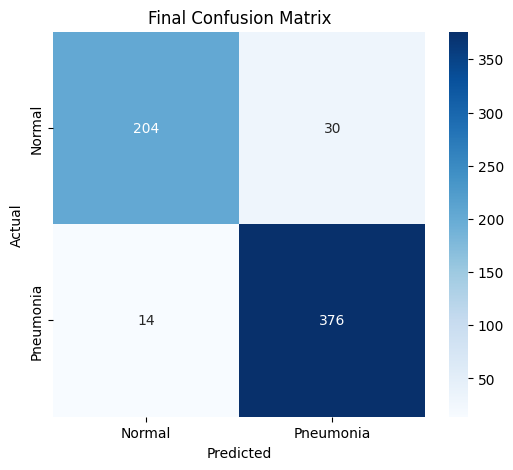

✅ 模型已保存至 Drive


In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

# ==========================================
# 1. 强制解压 (使用你提供的精准路径)
# ==========================================
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/kaggle_data/pneumonia_dataset.zip'
extract_path = '/content/dataset_temp'

if os.path.exists(zip_path):
    print("✅ 找到 ZIP 文件，正在解压...")
    !rm -rf {extract_path}
    !mkdir -p {extract_path}
    !unzip -o -q "{zip_path}" -d {extract_path}
    print("🎉 解压完成！")
else:
    raise FileNotFoundError(f"❌ 依然找不到文件: {zip_path}，请确认左侧文件栏路径是否一致。")

# ==========================================
# 2. 路径自动对齐
# ==========================================
base_path = None
for root, dirs, files in os.walk(extract_path):
    if 'train' in dirs and 'test' in dirs:
        base_path = root
        break

if not base_path:
    raise ValueError("❌ 压缩包结构异常，未找到 train/test 文件夹。")

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
# 通常 Kaggle 数据集 val 文件夹较小，有时需要从 train 中分出，这里优先寻找原有的 val
val_dir = os.path.join(base_path, 'val') if 'val' in os.listdir(base_path) else test_dir

print(f"📍 训练路径: {train_dir}")
print(f"📍 测试路径: {test_dir}")

# ==========================================
# 3. 数据增强与加载
# ==========================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

val_generator = test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32, class_mode='binary', shuffle=False)

# ==========================================
# 4. 构建并训练 CNN 模型 (12 Epochs)
# ==========================================
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # 提高泛化能力[cite: 1]
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n🚀 开始模型训练...")
history = model.fit(
    train_generator,
    epochs=12, # 匹配你之前的运行轮数[cite: 1]
    validation_data=val_generator
)

# ==========================================
# 5. 生成可视化实验报告
# ==========================================
# A. 训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# B. 分类报告与混淆矩阵
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\n" + "="*30)
print("实验报告指标")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Final Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 保存结果到 Drive
model.save('/content/drive/MyDrive/hw07/trained_pneumonia_model.h5')
print("✅ 模型已保存至 Drive")